<a href="https://colab.research.google.com/github/rodrigogossi/ic_rodrigogossi_yollov8/blob/main/treinamento_repeated_kfold_640n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Repeated K-Fold Cross Validation — YOLOv8 Segmentação — 640px
Dataset: 542 imagens, 2 classes (fungo e escala)
Configuração: 3 repetições × 5 folds = 15 treinos
Ambiente: Google Colab

CÉLULA 1 — Instalação de dependências

In [3]:
!pip install -U ultralytics scikit-learn pandas pyyaml tqdm matplotlib

CÉLULA 2 - Imports

In [4]:
import datetime
import random
import shutil
import zipfile
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import yaml
from sklearn.model_selection import RepeatedKFold
from tqdm import tqdm
from ultralytics import YOLO


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


CÉLULA 3 — Configurações

In [5]:
#⚠️ Edite o caminho abaixo com o nome real da sua pasta no Drive
dataset_path = Path("/content/drive/MyDrive/ic-yollov8/dataset_bruto")  # ← EDITE AQUI

# Classes (ordem deve bater com o data.yaml exportado pelo Label Studio)
classes = {
    0: "escala",
    1: "fungo",
}

IMGSZ      = 640    # resolução deste notebook
N_SPLITS   = 5      # folds por repetição
N_REPEATS  = 3      # número de repetições
EPOCHS     = 100
BATCH      = 16
WEIGHTS    = "yolov8n-seg.pt"
SEED       = 42

# Pasta de saída salva diretamente no Drive (protege contra queda de sessão)
today      = datetime.date.today().isoformat()
save_path  = Path(f"/content/drive/MyDrive/ic-yollov8/resultados_{IMGSZ}px_{today}")
save_path.mkdir(parents=True, exist_ok=True)


CÉLULA 4 - Montar google drive

In [6]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


CÉLULA 5 — Validação da estrutura de pastas

In [7]:
images_dir = dataset_path / "images"
labels_dir = dataset_path / "labels"

assert images_dir.exists(), f"Pasta não encontrada: {images_dir}"
assert labels_dir.exists(), f"Pasta não encontrada: {labels_dir}"

SUPPORTED_EXT = [".jpg", ".jpeg", ".png"]
images = sorted([f for ext in SUPPORTED_EXT for f in images_dir.rglob(f"*{ext}")])
labels = sorted(labels_dir.rglob("*.txt"))

print(f"✅ Imagens encontradas : {len(images)}")
print(f"✅ Labels encontradas  : {len(labels)}")

image_stems   = {img.stem for img in images}
label_stems   = {lbl.stem for lbl in labels}
pares_validos = image_stems & label_stems

sem_label  = image_stems - label_stems
sem_imagem = label_stems - image_stems
if sem_label:
    print(f"⚠️  {len(sem_label)} imagem(ns) sem label — ignoradas")
if sem_imagem:
    print(f"⚠️  {len(sem_imagem)} label(s) sem imagem — ignoradas")

images = sorted([i for i in images if i.stem in pares_validos], key=lambda x: x.stem)
labels = sorted([l for l in labels if l.stem in pares_validos], key=lambda x: x.stem)

print(f"✅ Pares válidos: {len(images)}")


✅ Imagens encontradas : 542
✅ Labels encontradas  : 542
✅ Pares válidos: 542


CÉLULA 6 — Gerar DataFrame de features

In [8]:
cls_idx   = sorted(classes.keys())
index     = [lbl.stem for lbl in labels]
labels_df = pd.DataFrame(0.0, index=index, columns=cls_idx)

for label in labels:
    lbl_counter = Counter()
    with open(label) as lf:
        for line in lf.readlines():
            line = line.strip()
            if line:
                cls = int(line.split()[0])
                lbl_counter[cls] += 1
    labels_df.loc[label.stem] = [lbl_counter.get(c, 0) for c in cls_idx]

print("📊 Instâncias por classe:")
for c in cls_idx:
    print(f"  {classes[c]}: {int(labels_df[c].sum())}")


📊 Instâncias por classe:
  escala: 542
  fungo: 543


CÉLULA 7 — Repeated K-Fold split

In [12]:

random.seed(SEED)

rkf    = RepeatedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=SEED)
splits = list(rkf.split(labels_df))

split_names = [
    f"rep{r+1}_fold{f+1}"
    for r in range(N_REPEATS)
    for f in range(N_SPLITS)
]

folds_df = pd.DataFrame(index=index, columns=split_names)
for name, (train_idx, val_idx) in zip(split_names, splits):
    folds_df.loc[labels_df.index[train_idx], name] = "train"   # ← corrigido
    folds_df.loc[labels_df.index[val_idx],   name] = "val"     # ← corrigido

# Distribuição de classes por split
distr_df = pd.DataFrame(index=split_names, columns=cls_idx)
for name, (train_idx, val_idx) in zip(split_names, splits):
    ratio = labels_df.iloc[val_idx].sum() / (labels_df.iloc[train_idx].sum() + 1e-7)
    distr_df.loc[name] = ratio

print(f"\n📊 Razão val/train por split (ideal: valores similares entre splits):")
print(distr_df.round(3).to_string())


📊 Razão val/train por split (ideal: valores similares entre splits):
                   0         1
rep1_fold1  0.251732  0.251152
rep1_fold2  0.251732  0.251152
rep1_fold3  0.248848  0.248276
rep1_fold4  0.248848  0.248276
rep1_fold5  0.248848  0.251152
rep2_fold1  0.251732  0.254042
rep2_fold2  0.251732  0.251152
rep2_fold3  0.248848  0.248276
rep2_fold4  0.248848  0.248276
rep2_fold5  0.248848  0.248276
rep3_fold1  0.251732  0.251152
rep3_fold2  0.251732  0.251152
rep3_fold3  0.248848  0.248276
rep3_fold4  0.248848  0.248276
rep3_fold5  0.248848  0.251152


 CÉLULA 8 — Criar estrutura de pastas e YAMLs para cada split

In [13]:
label_map = {lbl.stem: lbl for lbl in labels}
ds_yamls  = []

for split_name in split_names:
    split_dir = save_path / "splits" / split_name
    for subset in ["train", "val"]:
        (split_dir / subset / "images").mkdir(parents=True, exist_ok=True)
        (split_dir / subset / "labels").mkdir(parents=True, exist_ok=True)

    yaml_path = split_dir / f"{split_name}_dataset.yaml"
    ds_yamls.append(yaml_path)

    with open(yaml_path, "w") as f:
        yaml.safe_dump(
            {"path": split_dir.as_posix(), "train": "train", "val": "val", "names": classes},
            f, allow_unicode=True,
        )

print(f"✅ Estrutura criada para {len(split_names)} splits")


✅ Estrutura criada para 15 splits


CÉLULA 9 — Copiar imagens e labels

In [14]:
for image in tqdm(images, desc="Copiando arquivos"):
    label = label_map.get(image.stem)
    if not label:
        continue
    for split_name in split_names:
        subset  = folds_df.loc[image.stem, split_name]
        shutil.copy(image, save_path / "splits" / split_name / subset / "images" / image.name)
        shutil.copy(label, save_path / "splits" / split_name / subset / "labels" / label.name)

print("✅ Cópia concluída!")

Copiando arquivos: 100%|██████████| 542/542 [13:48<00:00,  1.53s/it]

✅ Cópia concluída!


CÉLULA 10 — Treinar YOLOv8-seg em cada split
Salva no Drive a cada fold — protege contra queda de sessão

In [15]:
results     = {}
total       = len(ds_yamls)
log_entries = []

for k, (split_name, dataset_yaml) in enumerate(zip(split_names, ds_yamls), start=1):
    print(f"\n{'='*55}")
    print(f"🚀 [{k}/{total}]  {split_name}  —  {IMGSZ}px")
    print(f"{'='*55}")

    model = YOLO(WEIGHTS)
    result = model.train(
        data    = str(dataset_yaml),
        task    = "segment",
        epochs  = EPOCHS,
        batch   = BATCH,
        imgsz   = IMGSZ,
        project = str(save_path / "runs"),
        name    = split_name,
        seed    = SEED,
        verbose = False,
    )
    results[split_name] = result

    # Salva métricas parciais no Drive imediatamente após cada fold
    m = result.seg
    entry = {
        "split"     : split_name,
        "repeticao" : split_name.split("_")[0],   # rep1, rep2, rep3
        "fold"      : split_name.split("_")[1],   # fold1..fold5
        "mAP50"     : round(m.map50, 4),
        "mAP50-95"  : round(m.map,   4),
        "Precision" : round(m.mp,    4),
        "Recall"    : round(m.mr,    4),
    }
    log_entries.append(entry)

    # Grava CSV parcial — se a sessão cair, você não perde o que já foi feito
    pd.DataFrame(log_entries).to_csv(save_path / "metricas_parciais.csv", index=False)
    print(f"  💾 Métricas salvas no Drive ({k}/{total} concluídos)")

print("\n✅ Todos os splits treinados!")


Streaming output truncated to the last 5000 lines.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.5it/s 1.6s
                   all        109        218      0.854      0.919      0.915      0.809      0.854      0.919      0.912      0.802

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss   sem_loss  Instances       Size
     12/100      3.39G     0.5391     0.6738     0.4809     0.8942          0          2        640: 100% ━━━━━━━━━━━━ 28/28 3.4it/s 8.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.1it/s 1.9s
                   all        109        218      0.962      0.979       0.99      0.865      0.962      0.979      0.989      0.866

      Epoch    GPU_mem   box_loss   seg_loss   cls_loss   dfl_loss   sem_loss  Instances       Size
     

CÉLULA 11 — Tabela de resultados para o artigo

In [16]:
metrics_df = pd.DataFrame(log_entries).set_index("split")
num_cols   = ["mAP50", "mAP50-95", "Precision", "Recall"]

# Média e desvio por repetição
rep_stats = metrics_df.groupby("repeticao")[num_cols].agg(["mean", "std"]).round(4)

# Média e desvio geral (sobre todos os 15 treinos)
mean_geral = metrics_df[num_cols].mean().round(4).rename("Média Geral")
std_geral  = metrics_df[num_cols].std().round(4).rename("Desvio Padrão Geral")

table_df = pd.concat([metrics_df[num_cols], mean_geral.to_frame().T, std_geral.to_frame().T])

print("\n📊 Tabela completa de métricas:\n")
print(table_df.to_string())
print("\n📊 Média por repetição:\n")
print(rep_stats.to_string())

# Salva CSVs
table_df.to_csv(save_path / "metricas_completas.csv")
rep_stats.to_csv(save_path / "metricas_por_repeticao.csv")
folds_df.to_csv(save_path / "kfold_datasplit.csv")
distr_df.to_csv(save_path / "kfold_label_distribution.csv")
print("\n✅ CSVs salvos no Drive")



📊 Tabela completa de métricas:

                      mAP50  mAP50-95  Precision  Recall
rep1_fold1           0.9934    0.9055     0.9886  0.9902
rep1_fold2           0.9950    0.9232     0.9982  1.0000
rep1_fold3           0.9944    0.9285     0.9850  0.9940
rep1_fold4           0.9950    0.9126     0.9937  0.9975
rep1_fold5           0.9950    0.9236     0.9970  0.9995
rep2_fold1           0.9947    0.9158     0.9942  0.9937
rep2_fold2           0.9916    0.9175     0.9888  0.9908
rep2_fold3           0.9950    0.9157     0.9984  1.0000
rep2_fold4           0.9950    0.9169     0.9983  0.9954
rep2_fold5           0.9936    0.9230     0.9887  0.9954
rep3_fold1           0.9946    0.9206     0.9933  1.0000
rep3_fold2           0.9950    0.9038     0.9979  0.9950
rep3_fold3           0.9950    0.9227     0.9970  1.0000
rep3_fold4           0.9950    0.9206     0.9979  0.9954
rep3_fold5           0.9910    0.9201     0.9832  0.9862
Média Geral          0.9942    0.9180     0.9933  0.995

CÉLULA 12 — Gráfico comparativo para o artigo

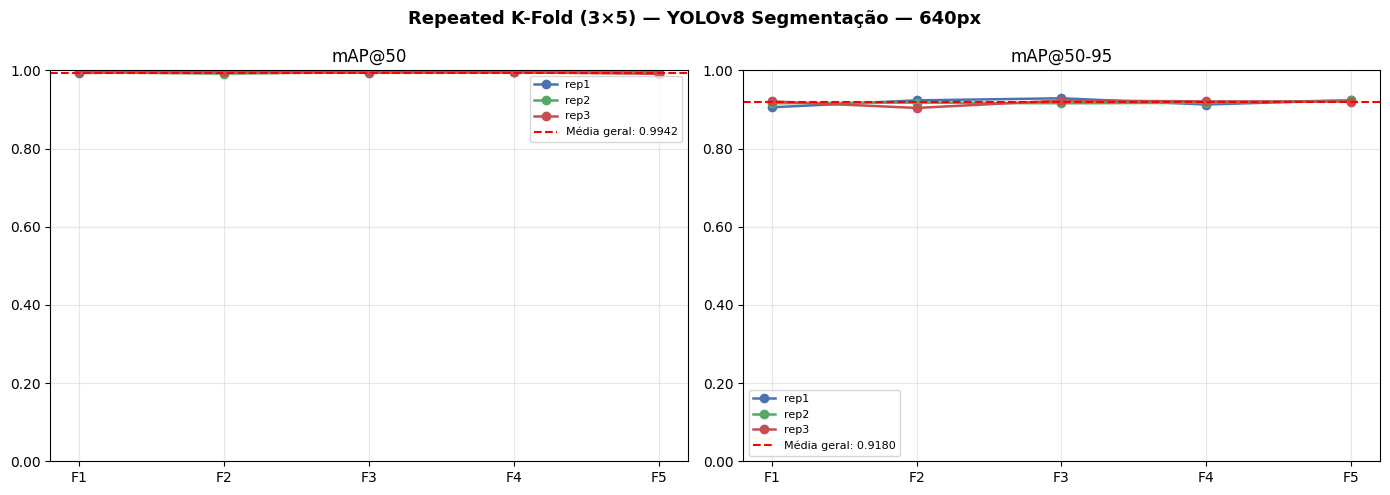

✅ Gráfico salvo: /content/drive/MyDrive/ic-yollov8/resultados_640px_2026-03-18/grafico_mAP_640px.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f"Repeated K-Fold ({N_REPEATS}×{N_SPLITS}) — YOLOv8 Segmentação — {IMGSZ}px",
    fontsize=13, fontweight="bold"
)

cores_rep = ["#4C72B0", "#55A868", "#C44E52"]  # uma cor por repetição

for ax, col, title in [
    (axes[0], "mAP50",    "mAP@50"),
    (axes[1], "mAP50-95", "mAP@50-95"),
]:
    for r, (rep_name, rep_df) in enumerate(metrics_df.groupby("repeticao")):
        x      = [f"F{i+1}" for i in range(N_SPLITS)]
        values = rep_df[col].values
        ax.plot(x, values, marker="o", label=rep_name, color=cores_rep[r], linewidth=1.8)

    # Linha de média geral
    ax.axhline(
        metrics_df[col].mean(), color="red", linestyle="--", linewidth=1.5,
        label=f"Média geral: {metrics_df[col].mean():.4f}"
    )
    ax.set_title(title)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
chart_path = save_path / f"grafico_mAP_{IMGSZ}px.png"
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Gráfico salvo: {chart_path}")


CÉLULA 13 — Organizar arquivos para o artigo e gerar ZIP

In [18]:


artigo_path = save_path / "para_artigo"
(artigo_path / "pesos").mkdir(parents=True, exist_ok=True)
(artigo_path / "graficos").mkdir(parents=True, exist_ok=True)
(artigo_path / "matrizes_confusao").mkdir(parents=True, exist_ok=True)
(artigo_path / "metricas").mkdir(parents=True, exist_ok=True)

runs_path = save_path / "runs"

for split_name in split_names:
    fold_run = runs_path / split_name
    if not fold_run.exists():
        print(f"⚠️  Não encontrado: {fold_run}")
        continue

    # Pesos
    for w in ["best.pt", "last.pt"]:
        src = fold_run / "weights" / w
        if src.exists():
            shutil.copy(src, artigo_path / "pesos" / f"{split_name}_{w}")

    # Gráficos gerados pelo YOLO
    for f in fold_run.glob("*.png"):
        shutil.copy(f, artigo_path / "graficos" / f"{split_name}_{f.name}")

    # Matrizes de confusão
    for f in fold_run.glob("confusion_matrix*.png"):
        shutil.copy(f, artigo_path / "matrizes_confusao" / f"{split_name}_{f.name}")

# Gráfico comparativo
shutil.copy(chart_path, artigo_path / "graficos" / chart_path.name)

# CSVs
for csv_name in ["metricas_completas.csv", "metricas_por_repeticao.csv",
                 "kfold_datasplit.csv", "kfold_label_distribution.csv"]:
    src = save_path / csv_name
    if src.exists():
        shutil.copy(src, artigo_path / "metricas" / csv_name)

# ZIP salvo direto no Drive
zip_path = save_path / f"artigo_{IMGSZ}px_{today}.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for file in sorted(artigo_path.rglob("*")):
        if file.is_file():
            zf.write(file, arcname=file.relative_to(artigo_path))

zip_mb = zip_path.stat().st_size / (1024 ** 2)
print(f"✅ ZIP salvo no Drive: {zip_path}")
print(f"   Tamanho: {zip_mb:.1f} MB")

✅ ZIP salvo no Drive: /content/drive/MyDrive/ic-yollov8/resultados_640px_2026-03-18/artigo_640px_2026-03-18.zip
   Tamanho: 194.0 MB


CÉLULA 14 — Resumo final no console

In [19]:

print("\n" + "="*60)
print(f"  RESUMO FINAL — Repeated K-Fold {N_REPEATS}×{N_SPLITS} — {IMGSZ}px")
print("="*60)
print(table_df.to_string())
print("="*60)
print(f"\n📦 Estrutura do ZIP:")
print("   ├── pesos/              → best.pt e last.pt de cada split")
print("   ├── graficos/           → curvas de treino + comparativo mAP")
print("   ├── matrizes_confusao/  → confusion matrix de cada split")
print("   └── metricas/")
print("       ├── metricas_completas.csv      → todos os 15 splits")
print("       ├── metricas_por_repeticao.csv  → média e desvio por repetição")
print("       ├── kfold_datasplit.csv")
print("       └── kfold_label_distribution.csv")


  RESUMO FINAL — Repeated K-Fold 3×5 — 640px
                      mAP50  mAP50-95  Precision  Recall
rep1_fold1           0.9934    0.9055     0.9886  0.9902
rep1_fold2           0.9950    0.9232     0.9982  1.0000
rep1_fold3           0.9944    0.9285     0.9850  0.9940
rep1_fold4           0.9950    0.9126     0.9937  0.9975
rep1_fold5           0.9950    0.9236     0.9970  0.9995
rep2_fold1           0.9947    0.9158     0.9942  0.9937
rep2_fold2           0.9916    0.9175     0.9888  0.9908
rep2_fold3           0.9950    0.9157     0.9984  1.0000
rep2_fold4           0.9950    0.9169     0.9983  0.9954
rep2_fold5           0.9936    0.9230     0.9887  0.9954
rep3_fold1           0.9946    0.9206     0.9933  1.0000
rep3_fold2           0.9950    0.9038     0.9979  0.9950
rep3_fold3           0.9950    0.9227     0.9970  1.0000
rep3_fold4           0.9950    0.9206     0.9979  0.9954
rep3_fold5           0.9910    0.9201     0.9832  0.9862
Média Geral          0.9942    0.9180     